## Limpieza de datos

https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset

1. Reemplazar los números de pedido por {{Order Number}}
2. Reemplazar números de factura por {{Invoice Number}}
3. Generar columnas con la longitud de 'instruction', 'response'
4. Separar la columna 'flags' por booleanos según su presencia
5. Identificar {{}}

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [4]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,is it possible to place an order from {{Delive...,ACCOUNT,contact_customer_service,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


---

## 1. Reemplazar los números de pedido por {{Order Number}}

In [5]:
df[(~df.instruction.str.contains('{{Order Number}}')) & (df.category == 'ORDER')]

,flags,instruction,category,intent,response
62,BCELNV,I cannot pay for the last purchase I have made...,ORDER,cancel_order,I gather that you're unable to make the paymen...
66,BLWZ,help me to cancel my last goddamn purchase,ORDER,cancel_order,I've picked up that you're feeling frustrated ...
83,BK,cancelling order,ORDER,cancel_order,I've come to understand that you would like to...
166,BIMP,would you give me information about cancelling...,ORDER,cancel_order,Of course! I'd be happy to provide you with in...
198,BCLM,"I purchased some item, help canceling one of t...",ORDER,cancel_order,I understand your request for assistance with ...
...,...,...,...,...,...
25684,BK,status of order,ORDER,track_order,I see what you mean! I'm on the same page that...
25711,BKLZ,order 113542617735902current status,ORDER,track_order,Your reach-out is appreciated! I'm sensing tha...
25775,BIQZ,how do i check the eta of order00123842,ORDER,track_order,Thank you for reaching out! I can definitely a...
25784,BK,order status,ORDER,track_order,Your reach-out is appreciated! I'm sensing tha...


In [6]:
df[df.category == 'ORDER'].instruction.str.extract(r"(\d{2,20})").value_counts()

0              
00123842           8
732201349959       8
113542617735902    8
370795561790       7
00004587345        6
Name: count, dtype: int64

In [7]:
df['instruction_clean'] = df['instruction']

In [8]:
df.loc[df['category'] == 'ORDER', 'instruction_clean'] = df.instruction.str.replace(r"(\d{2,20})", '{{Order Number}}', regex=True)

In [9]:
df[df.category == 'ORDER'].instruction_clean.value_counts()

instruction_clean
see order {{Order Number}} status                                  5
problem with cancelling purchase {{Order Number}}                  5
modify order{{Order Number}}                                       5
can you help me cancel purchase {{Order Number}}?                  5
add item to order {{Order Number}}                                 5
                                                                  ..
I no longer want order {{Order Number}}, how do I cancel it?       1
I purchased some items, I want to cancel order {{Order Number}}    1
i do not know how i could casncel order {{Order Number}}           1
help  me canceling purchase {{Order Number}}                       1
want assistance checking the eta of order {{Order Number}}         1
Name: count, Length: 3152, dtype: int64

---

## 2. Reemplazar números de factura por {{Invoice Number}}

In [10]:
df[(~df.instruction.str.contains('{{Invoice Number}}')) & (df.category == 'INVOICE')]

,flags,instruction,category,intent,response,instruction_clean
3919,BLMQZ,need to see my invoicesfrom {{Person Name}},INVOICE,check_invoice,Certainly! I understand that you are looking t...,need to see my invoicesfrom {{Person Name}}
3920,BCL,"I have to see my invoice from {{Person Name}},...",INVOICE,check_invoice,I'm on it! I understand your urgency to view t...,"I have to see my invoice from {{Person Name}},..."
3921,BIL,can you help me seeing the invoice from {{Pers...,INVOICE,check_invoice,Of course! I understand that you need assistan...,can you help me seeing the invoice from {{Pers...
3922,BIL,how can I locate the invoice #37777?,INVOICE,check_invoice,I certainly recognize your confusion about loc...,how can I locate the invoice #37777?
3923,BLMW,I need to look for the fucking invoices from {...,INVOICE,check_invoice,I see your urgency to locate the invoices from...,I need to look for the fucking invoices from {...
...,...,...,...,...,...,...
15893,BELQ,i do not know how to download my bill from {{P...,INVOICE,get_invoice,I see what you mean your uncertainty about how...,i do not know how to download my bill from {{P...
15894,BCL,I want to download the invoice from {{Person N...,INVOICE,get_invoice,I hear you loud and clear your need to downloa...,I want to download the invoice from {{Person N...
15895,BLQZ,i dont know what to do to getmy bill #37777,INVOICE,get_invoice,I understand your uncertainty about how to ret...,i dont know what to do to getmy bill #37777
15896,BKL,download bill #12588,INVOICE,get_invoice,Certainly! I completely understand your need t...,download bill #12588


In [11]:
df[df.category == 'INVOICE'].instruction.str.extract(r"(\#\d{2,20})").value_counts()

0     
#37777    268
#12588    263
#00108    257
#85632    249
Name: count, dtype: int64

In [12]:
df.loc[df['category'] == 'INVOICE', 'instruction_clean'] = df.instruction.str.replace(r"(\#\d{2,20})", '{{Invoice Number}}', regex=True)

In [13]:
df[df.category == 'INVOICE'].instruction_clean.value_counts()

instruction_clean
check bill from {{Person Name}}                                      5
seeing bill from {{Person Name}}                                     5
checking invoices from {{Person Name}}                               5
getbills from {{Person Name}}                                        5
check invoices from {{Person Name}}                                  5
                                                                    ..
I don't know how I can download invoice {{Invoice Number}}           1
help me getting the bill from {{Person Name}}                        1
i do not know how i can download the invoice from {{Person Name}}    1
i wanr help downloading the invoice from {{Person Name}}             1
I need to look for the fucking invoices from {{Person Name}}         1
Name: count, Length: 1671, dtype: int64

---

## 3. Generar columnas con la longitud de 'instruction', 'response'

In [14]:
df['response_len'] = df.response.str.len()

In [15]:
df['instruction_len'] = df.instruction_clean.str.len()

<Axes: xlabel='response_len', ylabel='instruction_len'>

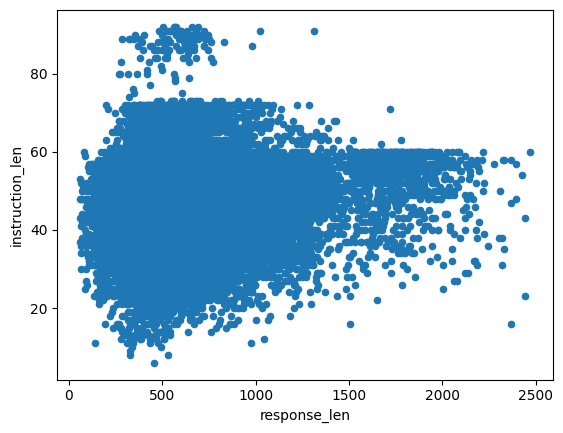

In [16]:
df[['response_len', 'instruction_len']].plot(x='response_len', y='instruction_len', kind='scatter')

---

## 4. Separar la columna 'flags' por booleanos según su presencia

In [17]:
df['flags'].value_counts()

flags
BL        5212
BLQ       2467
BIL       2138
BLM       1297
BILQ      1057
          ... 
BIPQWZ       1
BENQWZ       1
BPQWZ        1
BKQZ         1
BELMNW       1
Name: count, Length: 394, dtype: int64

In [18]:
flag_unique_values = set(df['flags'].sum())
print(flag_unique_values)

{'B', 'Z', 'I', 'K', 'Q', 'S', 'L', 'V', 'C', 'N', 'E', 'M', 'P', 'W'}


In [19]:
for flag in flag_unique_values:
    df[f"flag_{flag}"] = df['flags'].str.contains(flag)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   flags              26872 non-null  object
 1   instruction        26872 non-null  object
 2   category           26872 non-null  object
 3   intent             26872 non-null  object
 4   response           26872 non-null  object
 5   instruction_clean  26872 non-null  object
 6   response_len       26872 non-null  int64 
 7   instruction_len    26872 non-null  int64 
 8   flag_B             26872 non-null  bool  
 9   flag_Z             26872 non-null  bool  
 10  flag_I             26872 non-null  bool  
 11  flag_K             26872 non-null  bool  
 12  flag_Q             26872 non-null  bool  
 13  flag_S             26872 non-null  bool  
 14  flag_L             26872 non-null  bool  
 15  flag_V             26872 non-null  bool  
 16  flag_C             26872 non-null  bool 

In [21]:
df.flag_C.value_counts()

flag_C
False    24226
True      2646
Name: count, dtype: int64

---

## 5. Identificar {{}}

In [22]:
entities = df[~df.instruction_clean.isna()].instruction_clean.str.extract(r"(\{\{.*?\}\})")[0].dropna().unique()

In [23]:
for entity in entities:
    column_name = f"has_{entity.replace("{", "").replace("}", "").replace(" ", "_").lower()}"
    df[column_name] = df.instruction_clean.str.contains(entity)

In [24]:
df.has_order_number.value_counts()

has_order_number
False    23928
True      2944
Name: count, dtype: int64

---

# Resultado

In [25]:
df['instruction'] = df['instruction_clean']
df = df.drop(columns=['instruction_clean', 'flags'])
#df = df.drop(columns=['instruction_clean'])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   instruction           26872 non-null  object
 1   category              26872 non-null  object
 2   intent                26872 non-null  object
 3   response              26872 non-null  object
 4   response_len          26872 non-null  int64 
 5   instruction_len       26872 non-null  int64 
 6   flag_B                26872 non-null  bool  
 7   flag_Z                26872 non-null  bool  
 8   flag_I                26872 non-null  bool  
 9   flag_K                26872 non-null  bool  
 10  flag_Q                26872 non-null  bool  
 11  flag_S                26872 non-null  bool  
 12  flag_L                26872 non-null  bool  
 13  flag_V                26872 non-null  bool  
 14  flag_C                26872 non-null  bool  
 15  flag_N                26872 non-null

In [27]:
df.to_parquet('bitext-limpio.parquet')